# Dissertation-Quality Exploratory Dataset Analysis

This notebook audits the **AICOM Maltese Garbage Bag Detection** object-detection dataset prepared in YOLO format. It replaces the earlier descriptive visual checks with a reproducible, statistically grounded exploratory data analysis suitable for an MSc dissertation chapter.

The analysis focuses on dataset composition, split integrity, class imbalance, bounding-box geometry, object spatial distribution, annotation quality, dataset diversity, and representative visual examples. The outputs are designed to support later methodological choices for model training, augmentation, class weighting, input resizing, and evaluation protocol.


## Critical Review of the Previous Notebook

The original notebook provided a useful first inspection of the dataset, but several limitations reduced its suitability for dissertation inclusion:

- It relied heavily on random sample grids and simple count plots, with limited statistical interpretation.
- Several plots were redundant, particularly the class bar chart and pie chart; the pie chart obscured absolute imbalance and is less useful for technical reporting.
- Bounding-box geometry was not analysed beyond object counts, leaving object scale, aspect ratio, and area distributions unexplored.
- Split comparisons were limited to image and box totals, without checking whether validation and test splits preserve class proportions or object-size distributions.
- Annotation quality checks were missing, including malformed YOLO rows, out-of-range coordinates, empty labels, duplicate boxes, and extreme small/large boxes.
- Spatial object placement was visualised, but the previous heatmap used a dense raster accumulation of full boxes and did not separately inspect object centres or class-specific placement.
- Image resolution, Roboflow augmentation suffixes, and filename-derived temporal coverage were not examined.
- The notebook did not conclude with an analytical discussion linking dataset characteristics to training and evaluation decisions.

The revised notebook addresses these weaknesses by constructing image-level and annotation-level data frames, then deriving all figures and tables from those verified structures.


In [1]:
from __future__ import annotations

import hashlib
import math
import re
from collections import Counter
from pathlib import Path
from typing import Iterable

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from PIL import Image
from IPython.display import Markdown, display
from scipy.spatial.distance import jensenshannon
from scipy.stats import chi2_contingency, kruskal, spearmanr

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.frameon": False,
})
sns.set_theme(context="paper", style="whitegrid", palette="colorblind")

def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root from either Jupyter or command-line execution."""
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "Versions" / "AICOM-YOLOv26" / "data.yaml").exists():
            return candidate
    raise FileNotFoundError("Could not locate Versions/AICOM-YOLOv26/data.yaml from the current working directory.")


PROJECT_ROOT = find_project_root()
DATASET_ROOT = PROJECT_ROOT / "Versions" / "AICOM-YOLOv26"
DATA_YAML = DATASET_ROOT / "data.yaml"
SPLITS = ["train", "valid", "test"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

with DATA_YAML.open("r", encoding="utf-8") as f:
    dataset_config = yaml.safe_load(f)

CLASSES = list(dataset_config["names"])
CLASS_TO_ID = {name: idx for idx, name in enumerate(CLASSES)}
CLASS_COLORS = dict(zip(CLASSES, sns.color_palette("colorblind", n_colors=len(CLASSES))))

print(f"Dataset root: {DATASET_ROOT}")
print(f"Classes ({len(CLASSES)}): {', '.join(CLASSES)}")
print(f"Roboflow version: {dataset_config.get('roboflow', {}).get('version', 'not recorded')}")

Dataset root: /Volumes/Filis SSD/1. UM-Staff/AICOM/AICOM-OD/Versions/AICOM-YOLOv26
Classes (5): Mixed Waste, Orange CMD, Organic Waste, Other Waste, Recyclable Material
Roboflow version: 18


## Reproducible Data Ingestion

The following cell parses every image and label file into two canonical tables:

- `images_df`: one row per image, including split, dimensions, file metadata, and object count.
- `boxes_df`: one row per bounding box, including normalised and pixel-space YOLO geometry.

Annotation issues are collected in `quality_issues` rather than silently ignored. This makes the EDA auditable and prevents invalid labels from contaminating later statistical summaries.


In [2]:
def stable_hash(path: Path, block_size: int = 1 << 20) -> str:
    digest = hashlib.md5()
    with path.open("rb") as f:
        while chunk := f.read(block_size):
            digest.update(chunk)
    return digest.hexdigest()



def parse_capture_date(file_name: str) -> pd.Timestamp | pd.NaT:
    stem = file_name.split(".rf.")[0]
    patterns = [r"(20\d{6})", r"(20\d{2})[-_](\d{2})[-_](\d{2})"]
    match = re.search(patterns[0], stem)
    if match:
        return pd.to_datetime(match.group(1), format="%Y%m%d", errors="coerce")
    match = re.search(patterns[1], stem)
    if match:
        return pd.to_datetime("-".join(match.groups()), errors="coerce")
    return pd.NaT


def original_stem(file_name: str) -> str:
    return file_name.split(".rf.")[0]


def image_paths(split: str) -> list[Path]:
    images_dir = DATASET_ROOT / split / "images"
    return sorted(p for p in images_dir.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS)


def read_image_shape(path: Path) -> tuple[int | None, int | None, int | None]:
    try:
        with Image.open(path) as image:
            width, height = image.size
            channels = len(image.getbands())
        return int(width), int(height), int(channels)
    except Exception:
        return None, None, None


def parse_yolo_label(label_path: Path, image_id: str, split: str, img_w: int, img_h: int) -> tuple[list[dict], list[dict]]:
    rows, issues = [], []
    if not label_path.exists():
        issues.append({"image_id": image_id, "split": split, "issue": "missing_label_file", "line": None})
        return rows, issues

    lines = [line.strip() for line in label_path.read_text(encoding="utf-8").splitlines() if line.strip()]
    if not lines:
        issues.append({"image_id": image_id, "split": split, "issue": "empty_label_file", "line": None})
        return rows, issues

    seen_boxes = Counter()
    for line_no, line in enumerate(lines, start=1):
        parts = line.split()
        if len(parts) < 5:
            issues.append({"image_id": image_id, "split": split, "issue": "malformed_row", "line": line_no})
            continue
        try:
            class_id = int(float(parts[0]))
            x_center, y_center, box_w, box_h = map(float, parts[1:5])
        except ValueError:
            issues.append({"image_id": image_id, "split": split, "issue": "non_numeric_row", "line": line_no})
            continue

        if class_id < 0 or class_id >= len(CLASSES):
            issues.append({"image_id": image_id, "split": split, "issue": "invalid_class_id", "line": line_no})
            continue

        values = np.array([x_center, y_center, box_w, box_h], dtype=float)
        if not np.isfinite(values).all():
            issues.append({"image_id": image_id, "split": split, "issue": "non_finite_coordinate", "line": line_no})
            continue

        if box_w <= 0 or box_h <= 0:
            issues.append({"image_id": image_id, "split": split, "issue": "non_positive_box_size", "line": line_no})
            continue

        x_min_norm = x_center - box_w / 2
        y_min_norm = y_center - box_h / 2
        x_max_norm = x_center + box_w / 2
        y_max_norm = y_center + box_h / 2
        if (values < 0).any() or (values > 1).any() or x_min_norm < 0 or y_min_norm < 0 or x_max_norm > 1 or y_max_norm > 1:
            issues.append({"image_id": image_id, "split": split, "issue": "box_outside_image_bounds", "line": line_no})

        key = (class_id, round(x_center, 5), round(y_center, 5), round(box_w, 5), round(box_h, 5))
        seen_boxes[key] += 1
        if seen_boxes[key] > 1:
            issues.append({"image_id": image_id, "split": split, "issue": "duplicate_box", "line": line_no})

        rows.append({
            "image_id": image_id,
            "split": split,
            "class_id": class_id,
            "class_name": CLASSES[class_id],
            "x_center_norm": x_center,
            "y_center_norm": y_center,
            "box_width_norm": box_w,
            "box_height_norm": box_h,
            "x_min_norm": x_min_norm,
            "y_min_norm": y_min_norm,
            "x_max_norm": x_max_norm,
            "y_max_norm": y_max_norm,
            "box_area_norm": box_w * box_h,
            "aspect_ratio": box_w / box_h,
            "box_width_px": box_w * img_w,
            "box_height_px": box_h * img_h,
            "box_area_px": box_w * img_w * box_h * img_h,
        })
    return rows, issues


def build_dataset_tables() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    image_rows, box_rows, quality_rows = [], [], []
    for split in SPLITS:
        for path in image_paths(split):
            rel_path = path.relative_to(PROJECT_ROOT)
            image_id = f"{split}/{path.stem}"
            width, height, channels = read_image_shape(path)
            if width is None or height is None:
                quality_rows.append({"image_id": image_id, "split": split, "issue": "unreadable_image", "line": None})
                continue

            label_path = DATASET_ROOT / split / "labels" / f"{path.stem}.txt"
            boxes, issues = parse_yolo_label(label_path, image_id, split, width, height)
            box_rows.extend(boxes)
            quality_rows.extend(issues)

            image_rows.append({
                "image_id": image_id,
                "split": split,
                "image_path": path,
                "label_path": label_path,
                "relative_path": str(rel_path),
                "file_name": path.name,
                "original_stem": original_stem(path.name),
                "capture_date": parse_capture_date(path.name),
                "width": width,
                "height": height,
                "channels": channels,
                "image_area_px": width * height,
                "image_aspect_ratio": width / height,
                "object_count": len(boxes),
                "file_size_kb": path.stat().st_size / 1024,
            })

    images = pd.DataFrame(image_rows)
    boxes = pd.DataFrame(box_rows)
    quality = pd.DataFrame(quality_rows)

    if not boxes.empty:
        per_image = boxes.groupby("image_id").agg(
            mean_box_area_norm=("box_area_norm", "mean"),
            median_box_area_norm=("box_area_norm", "median"),
            min_box_area_norm=("box_area_norm", "min"),
            max_box_area_norm=("box_area_norm", "max"),
            mean_aspect_ratio=("aspect_ratio", "mean"),
            class_richness=("class_name", "nunique"),
        ).reset_index()
        images = images.merge(per_image, on="image_id", how="left")

    fill_cols = ["mean_box_area_norm", "median_box_area_norm", "min_box_area_norm", "max_box_area_norm", "mean_aspect_ratio", "class_richness"]
    for col in fill_cols:
        if col in images:
            images[col] = images[col].fillna(0)

    return images, boxes, quality

images_df, boxes_df, quality_issues = build_dataset_tables()

summary = pd.DataFrame({
    "images": images_df.groupby("split").size(),
    "boxes": boxes_df.groupby("split").size(),
    "mean_objects_per_image": images_df.groupby("split")["object_count"].mean(),
    "median_objects_per_image": images_df.groupby("split")["object_count"].median(),
}).reindex(SPLITS)
summary.loc["all", :] = [len(images_df), len(boxes_df), images_df["object_count"].mean(), images_df["object_count"].median()]

display(summary.style.format({
    "images": "{:.0f}",
    "boxes": "{:.0f}",
    "mean_objects_per_image": "{:.2f}",
    "median_objects_per_image": "{:.1f}",
}))
print(f"Image rows: {len(images_df):,}; bounding-box rows: {len(boxes_df):,}; quality flags: {len(quality_issues):,}")


,images,boxes,mean_objects_per_image,median_objects_per_image
split,,,,
train,29498,210274,7.13,6.0
valid,369,1072,2.91,2.0
test,369,1106,3.00,2.0
all,30236,212452,7.03,6.0


Image rows: 30,236; bounding-box rows: 212,452; quality flags: 964


## Dataset Composition and Split Balance

This section evaluates whether the train, validation, and test partitions are appropriately balanced. A strong detection benchmark should reserve enough independent validation and test examples while preserving comparable class and object-density distributions.


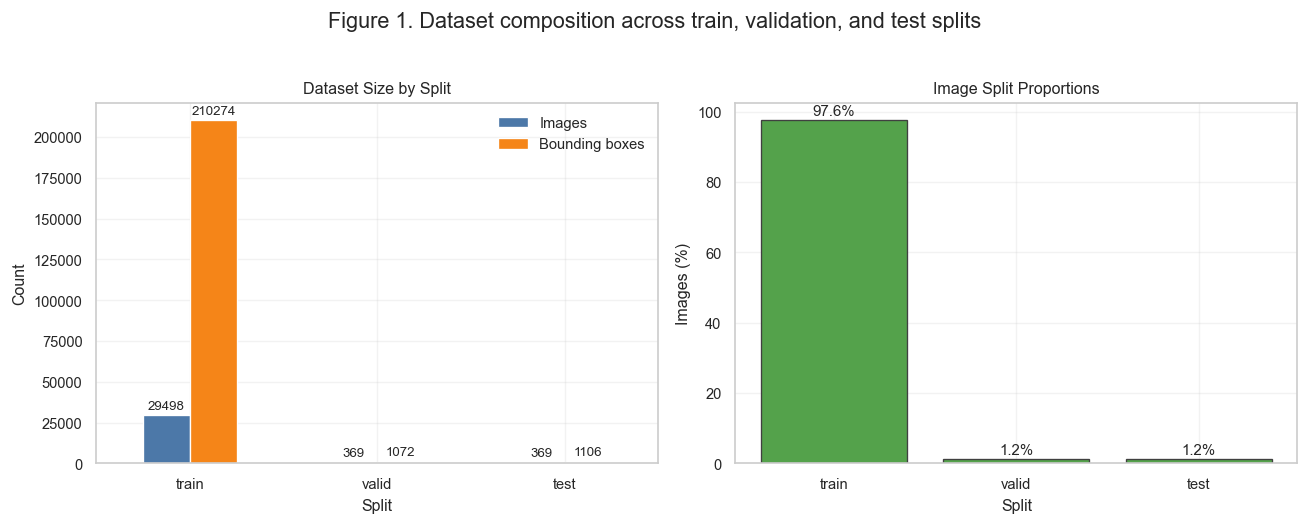

**Caption.** The dataset contains **30,236 images** and **212,452 annotated objects**. The training partition accounts for **97.6%** of images, while validation and test each account for **1.2%** and **1.2%**, respectively.

In [3]:
def add_bar_labels(ax, fmt="{:.0f}", padding=2):
    for container in ax.containers:
        labels = []
        for value in container.datavalues:
            labels.append(fmt.format(value) if value > 0 else "")
        ax.bar_label(container, labels=labels, padding=padding, fontsize=8)

split_counts = images_df["split"].value_counts().reindex(SPLITS)
split_box_counts = boxes_df["split"].value_counts().reindex(SPLITS)
split_plot_df = pd.DataFrame({"Images": split_counts, "Bounding boxes": split_box_counts}).reset_index().rename(columns={"index": "split"})

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
split_plot_df.plot(x="split", y=["Images", "Bounding boxes"], kind="bar", ax=axes[0], color=["#4C78A8", "#F58518"])
axes[0].set_title("Dataset Size by Split")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
add_bar_labels(axes[0])

split_percent = split_counts / split_counts.sum() * 100
axes[1].bar(split_percent.index, split_percent.values, color="#54A24B", edgecolor="0.25")
axes[1].set_title("Image Split Proportions")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Images (%)")
for i, value in enumerate(split_percent.values):
    axes[1].text(i, value + 0.5, f"{value:.1f}%", ha="center", va="bottom", fontsize=9)

fig.suptitle("Figure 1. Dataset composition across train, validation, and test splits", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()

display(Markdown(
    f"**Caption.** The dataset contains **{len(images_df):,} images** and **{len(boxes_df):,} annotated objects**. "
    f"The training partition accounts for **{split_percent.loc['train']:.1f}%** of images, while validation and test each account for "
    f"**{split_percent.loc['valid']:.1f}%** and **{split_percent.loc['test']:.1f}%**, respectively."
))


split,train,valid,test,total,share_%,imbalance_vs_max
class_name,,,,,,
Mixed Waste,59386,274,334,59994,28.24,1.00
Orange CMD,14363,78,78,14519,6.83,4.13
Organic Waste,41417,196,178,41791,19.67,1.44
Other Waste,43106,261,278,43645,20.54,1.37
Recyclable Material,52002,263,238,52503,24.71,1.14


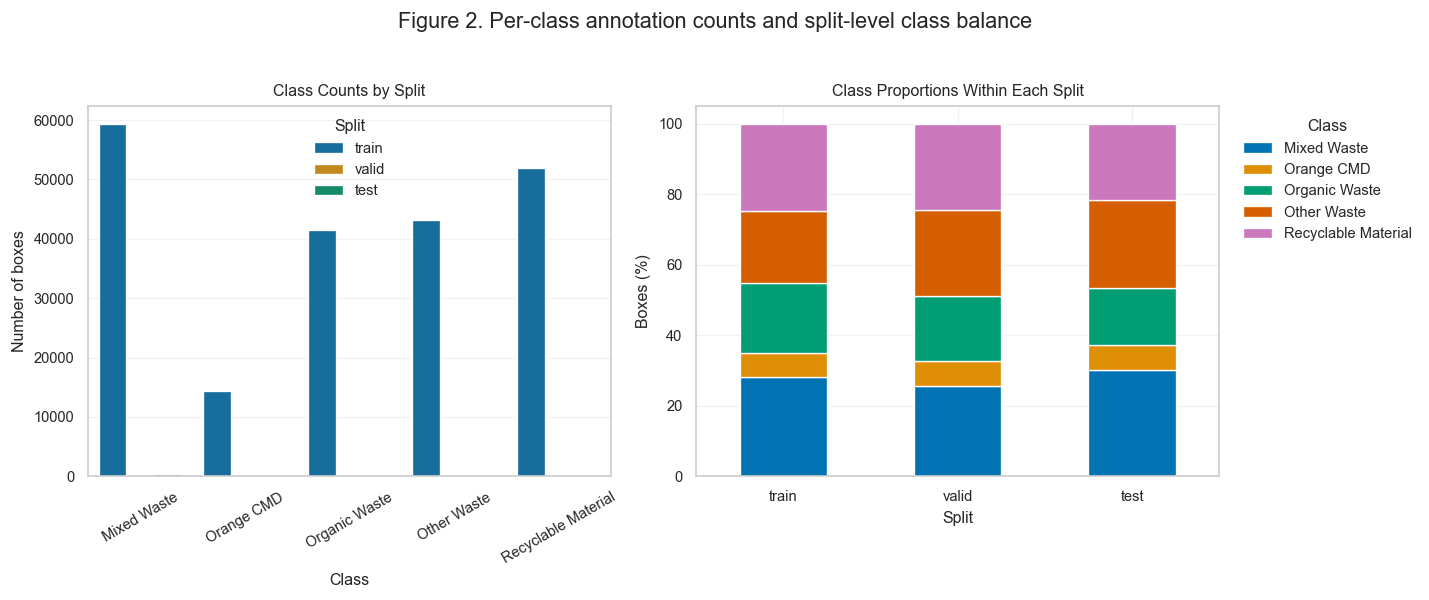

**Caption.** The largest-to-smallest class imbalance ratio is **4.13:1**. The Shannon class entropy is **2.21 bits** out of a possible **2.32 bits**, where higher values indicate a more even class distribution. A chi-square homogeneity test comparing class composition across splits gives **p = 1.34e-05**. Jensen-Shannon distances from the training distribution are **0.044** for validation and **0.064** for test.

In [4]:
class_by_split = pd.crosstab(boxes_df["class_name"], boxes_df["split"]).reindex(index=CLASSES, columns=SPLITS, fill_value=0)
class_by_split["total"] = class_by_split.sum(axis=1)
class_by_split["share_%"] = class_by_split["total"] / class_by_split["total"].sum() * 100
class_by_split["imbalance_vs_max"] = class_by_split["total"].max() / class_by_split["total"].replace(0, np.nan)

display(class_by_split.style.format({"share_%": "{:.2f}", "imbalance_vs_max": "{:.2f}"}))

plot_df = class_by_split[SPLITS].reset_index().melt(id_vars="class_name", var_name="split", value_name="count")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
sns.barplot(data=plot_df, x="class_name", y="count", hue="split", ax=axes[0], palette="colorblind")
axes[0].set_title("Class Counts by Split")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of boxes")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="Split")

prop_df = class_by_split[SPLITS].div(class_by_split[SPLITS].sum(axis=0), axis=1) * 100
prop_df.T.plot(kind="bar", stacked=True, ax=axes[1], color=[CLASS_COLORS[c] for c in CLASSES])
axes[1].set_title("Class Proportions Within Each Split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Boxes (%)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.suptitle("Figure 2. Per-class annotation counts and split-level class balance", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()

class_totals = class_by_split["total"]
imbalance_ratio = class_totals.max() / class_totals.min()
class_entropy = -(class_totals / class_totals.sum() * np.log2(class_totals / class_totals.sum())).sum()
max_entropy = np.log2(len(CLASSES))
chi2, p_value, dof, expected = chi2_contingency(class_by_split[SPLITS].T)

js_distances = {}
train_prop = prop_df["train"] / 100
for split in ["valid", "test"]:
    js_distances[split] = jensenshannon(train_prop, prop_df[split] / 100, base=2)

display(Markdown(
    f"**Caption.** The largest-to-smallest class imbalance ratio is **{imbalance_ratio:.2f}:1**. "
    f"The Shannon class entropy is **{class_entropy:.2f} bits** out of a possible **{max_entropy:.2f} bits**, where higher values indicate a more even class distribution. "
    f"A chi-square homogeneity test comparing class composition across splits gives **p = {p_value:.3g}**. "
    f"Jensen-Shannon distances from the training distribution are **{js_distances['valid']:.3f}** for validation and **{js_distances['test']:.3f}** for test."
))


## Object Density, Image Resolution, and Bounding-Box Geometry

Object detectors are sensitive to object scale, aspect ratio, crowding, and input resizing. The next figures quantify these characteristics directly from YOLO annotations.


/var/folders/3g/sbfzk_x1691fk8l_9_1fht100000gn/T/ipykernel_29517/64418105.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=images_df, x="split", y="object_count", order=SPLITS, ax=axes[1], palette="colorblind")


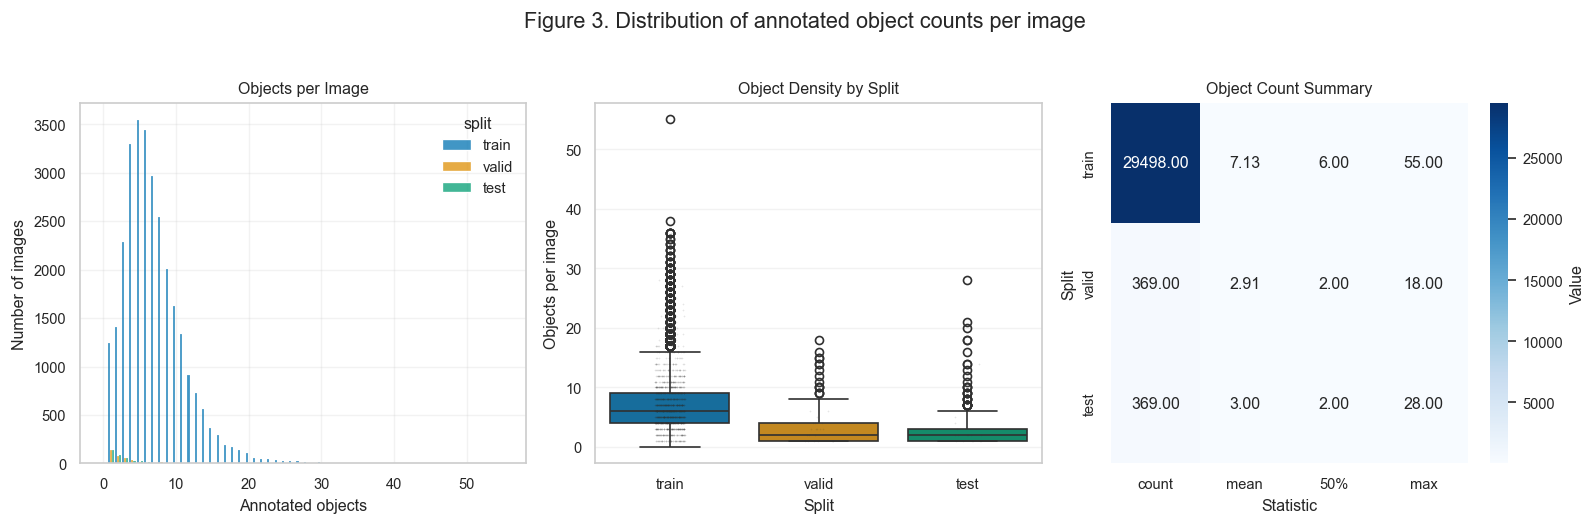

,count,mean,50%,max
split,,,,
train,29498.00,7.13,6.00,55.00
valid,369.00,2.91,2.00,18.00
test,369.00,3.00,2.00,28.00


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

max_objects = int(images_df["object_count"].max())
bins = np.arange(-0.5, max_objects + 1.5, 1)
sns.histplot(data=images_df, x="object_count", hue="split", multiple="dodge", bins=bins, shrink=0.85, ax=axes[0], palette="colorblind")
axes[0].set_title("Objects per Image")
axes[0].set_xlabel("Annotated objects")
axes[0].set_ylabel("Number of images")

sns.boxplot(data=images_df, x="split", y="object_count", order=SPLITS, ax=axes[1], palette="colorblind")
sns.stripplot(data=images_df.sample(min(1500, len(images_df)), random_state=RANDOM_SEED), x="split", y="object_count", order=SPLITS, ax=axes[1], color="0.2", alpha=0.12, size=1)
axes[1].set_title("Object Density by Split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Objects per image")

object_density_summary = images_df.groupby("split")["object_count"].describe()[["count", "mean", "50%", "max"]].reindex(SPLITS)
sns.heatmap(object_density_summary, annot=True, fmt=".2f", cmap="Blues", ax=axes[2], cbar_kws={"label": "Value"})
axes[2].set_title("Object Count Summary")
axes[2].set_xlabel("Statistic")
axes[2].set_ylabel("Split")

fig.suptitle("Figure 3. Distribution of annotated object counts per image", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()

display(object_density_summary.style.format("{:.2f}"))


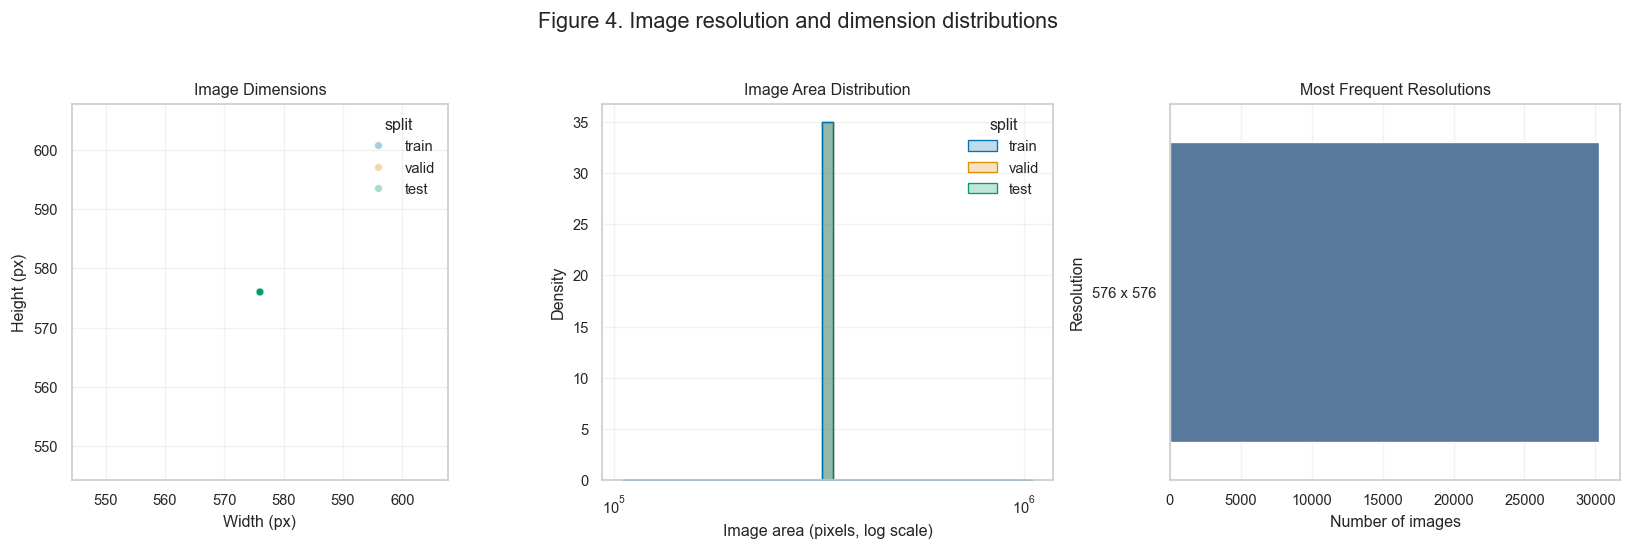

,images,unique_resolutions,median_width,median_height,median_area_px
split,,,,,
train,29498,1,576,576,331776
valid,369,1,576,576,331776
test,369,1,576,576,331776


In [6]:
resolution_df = images_df.copy()
resolution_df["resolution_label"] = resolution_df["width"].astype(str) + " x " + resolution_df["height"].astype(str)
resolution_counts = resolution_df["resolution_label"].value_counts().head(12)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
sns.scatterplot(data=resolution_df, x="width", y="height", hue="split", alpha=0.35, s=20, ax=axes[0], palette="colorblind")
axes[0].set_title("Image Dimensions")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Height (px)")
axes[0].set_aspect("equal", adjustable="box")

sns.histplot(data=resolution_df, x="image_area_px", hue="split", bins=35, log_scale=True, element="step", stat="density", common_norm=False, ax=axes[1], palette="colorblind")
axes[1].set_title("Image Area Distribution")
axes[1].set_xlabel("Image area (pixels, log scale)")
axes[1].set_ylabel("Density")

sns.barplot(x=resolution_counts.values, y=resolution_counts.index, ax=axes[2], color="#4C78A8")
axes[2].set_title("Most Frequent Resolutions")
axes[2].set_xlabel("Number of images")
axes[2].set_ylabel("Resolution")

fig.suptitle("Figure 4. Image resolution and dimension distributions", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()

resolution_summary = resolution_df.groupby("split").agg(
    images=("image_id", "count"),
    unique_resolutions=("resolution_label", "nunique"),
    median_width=("width", "median"),
    median_height=("height", "median"),
    median_area_px=("image_area_px", "median"),
).reindex(SPLITS)
display(resolution_summary.style.format("{:.0f}"))


/var/folders/3g/sbfzk_x1691fk8l_9_1fht100000gn/T/ipykernel_29517/1659168512.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=box_plot_df, x="class_name", y="box_area_%", ax=axes[0, 1], palette=[CLASS_COLORS[c] for c in CLASSES], showfliers=False)


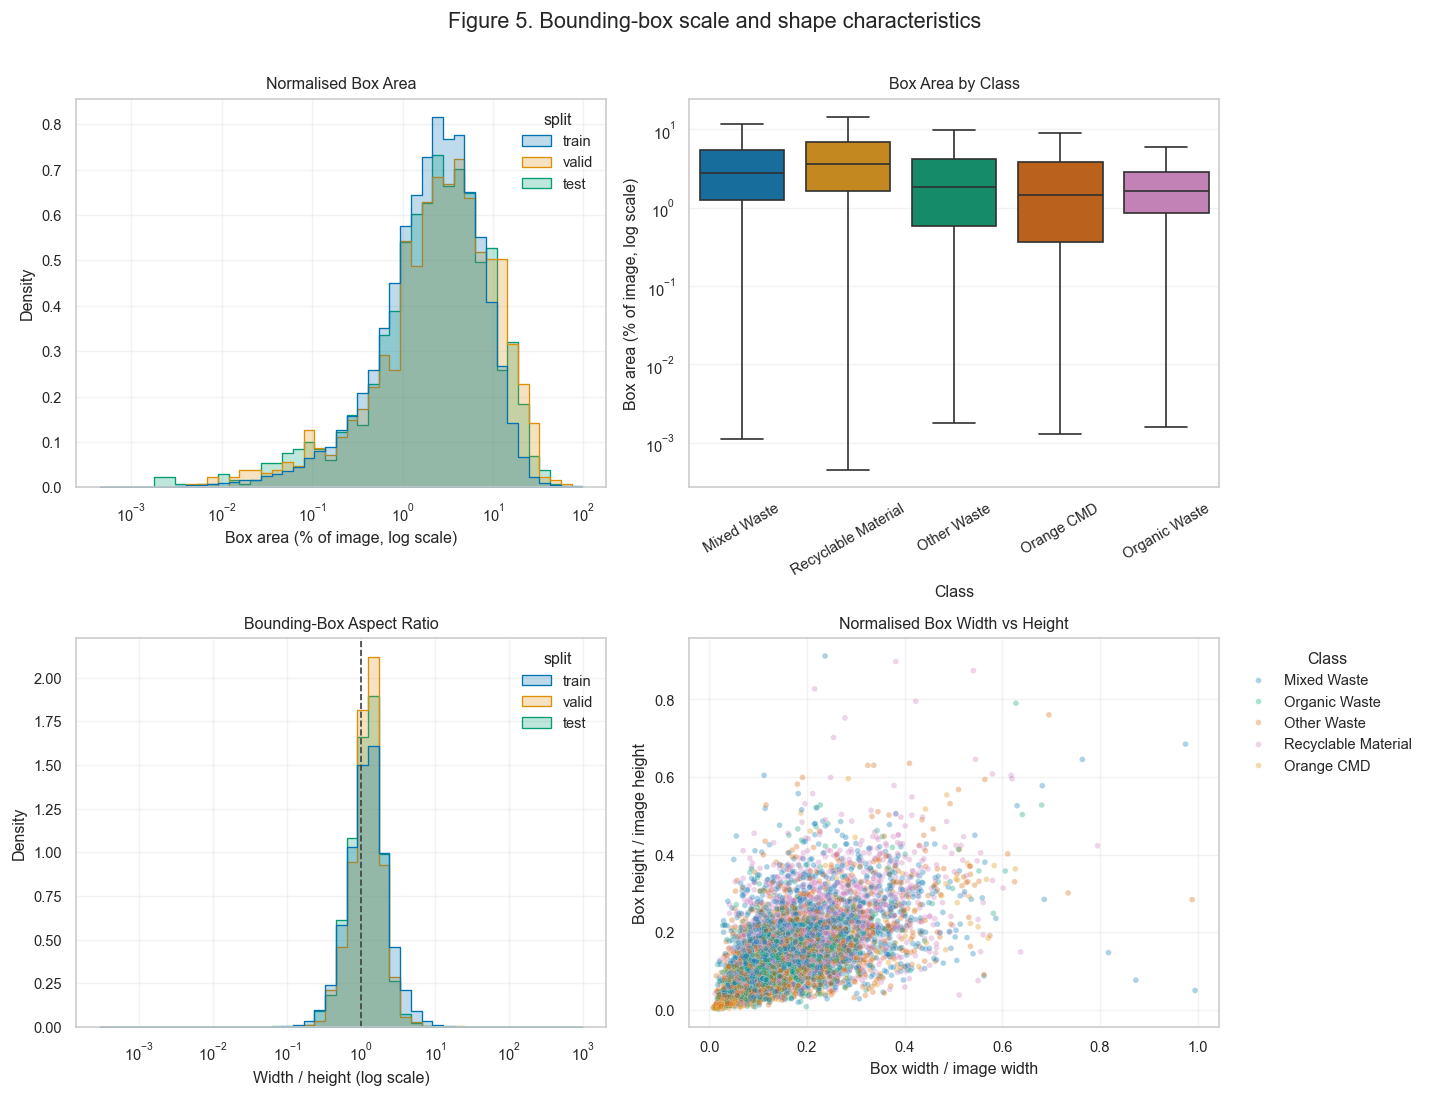

,boxes,median_area_pct,iqr_area_pct,median_aspect_ratio,median_width_px,median_height_px
class_name,,,,,,
Mixed Waste,59994,2.745,4.194,1.15,102,92
Orange CMD,14519,1.443,3.468,1.66,84,56
Organic Waste,41791,1.636,2.021,1.26,82,69
Other Waste,43645,1.817,3.645,1.31,86,70
Recyclable Material,52503,3.622,5.175,1.11,115,108


**Caption.** A Kruskal-Wallis test indicates whether normalised box area differs by class: **H = 15725.33, p = 0**.

In [7]:
box_plot_df = boxes_df.copy()
box_plot_df["box_area_%"] = box_plot_df["box_area_norm"] * 100
box_plot_df["log_aspect_ratio"] = np.log2(box_plot_df["aspect_ratio"])

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
sns.histplot(data=box_plot_df, x="box_area_%", hue="split", bins=45, log_scale=(True, False), element="step", stat="density", common_norm=False, ax=axes[0, 0], palette="colorblind")
axes[0, 0].set_title("Normalised Box Area")
axes[0, 0].set_xlabel("Box area (% of image, log scale)")
axes[0, 0].set_ylabel("Density")

sns.boxplot(data=box_plot_df, x="class_name", y="box_area_%", ax=axes[0, 1], palette=[CLASS_COLORS[c] for c in CLASSES], showfliers=False)
axes[0, 1].set_yscale("log")
axes[0, 1].set_title("Box Area by Class")
axes[0, 1].set_xlabel("Class")
axes[0, 1].set_ylabel("Box area (% of image, log scale)")
axes[0, 1].tick_params(axis="x", rotation=30)

sns.histplot(data=box_plot_df, x="aspect_ratio", hue="split", bins=45, log_scale=True, element="step", stat="density", common_norm=False, ax=axes[1, 0], palette="colorblind")
axes[1, 0].axvline(1, color="0.25", linestyle="--", linewidth=1)
axes[1, 0].set_title("Bounding-Box Aspect Ratio")
axes[1, 0].set_xlabel("Width / height (log scale)")
axes[1, 0].set_ylabel("Density")

sample_for_scatter = box_plot_df.sample(min(6000, len(box_plot_df)), random_state=RANDOM_SEED)
sns.scatterplot(data=sample_for_scatter, x="box_width_norm", y="box_height_norm", hue="class_name", alpha=0.32, s=12, ax=axes[1, 1], palette=CLASS_COLORS)
axes[1, 1].set_title("Normalised Box Width vs Height")
axes[1, 1].set_xlabel("Box width / image width")
axes[1, 1].set_ylabel("Box height / image height")
axes[1, 1].legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.suptitle("Figure 5. Bounding-box scale and shape characteristics", y=1.01, fontsize=13)
fig.tight_layout()
plt.show()

box_summary = boxes_df.groupby("class_name").agg(
    boxes=("image_id", "count"),
    median_area_pct=("box_area_norm", lambda s: s.median() * 100),
    iqr_area_pct=("box_area_norm", lambda s: (s.quantile(0.75) - s.quantile(0.25)) * 100),
    median_aspect_ratio=("aspect_ratio", "median"),
    median_width_px=("box_width_px", "median"),
    median_height_px=("box_height_px", "median"),
).reindex(CLASSES)
display(box_summary.style.format({
    "boxes": "{:.0f}",
    "median_area_pct": "{:.3f}",
    "iqr_area_pct": "{:.3f}",
    "median_aspect_ratio": "{:.2f}",
    "median_width_px": "{:.0f}",
    "median_height_px": "{:.0f}",
}))

area_samples = [boxes_df.loc[boxes_df["class_name"] == c, "box_area_norm"].values for c in CLASSES if (boxes_df["class_name"] == c).any()]
if len(area_samples) > 1:
    h_stat, h_p = kruskal(*area_samples)
    display(Markdown(f"**Caption.** A Kruskal-Wallis test indicates whether normalised box area differs by class: **H = {h_stat:.2f}, p = {h_p:.3g}**."))


## Spatial Distribution and Co-occurrence

Spatial bias can affect model generalisation: if objects are usually centred or confined to particular image regions, models may learn contextual priors in addition to object appearance. The following plots use normalised image coordinates so that images of different resolutions are comparable.


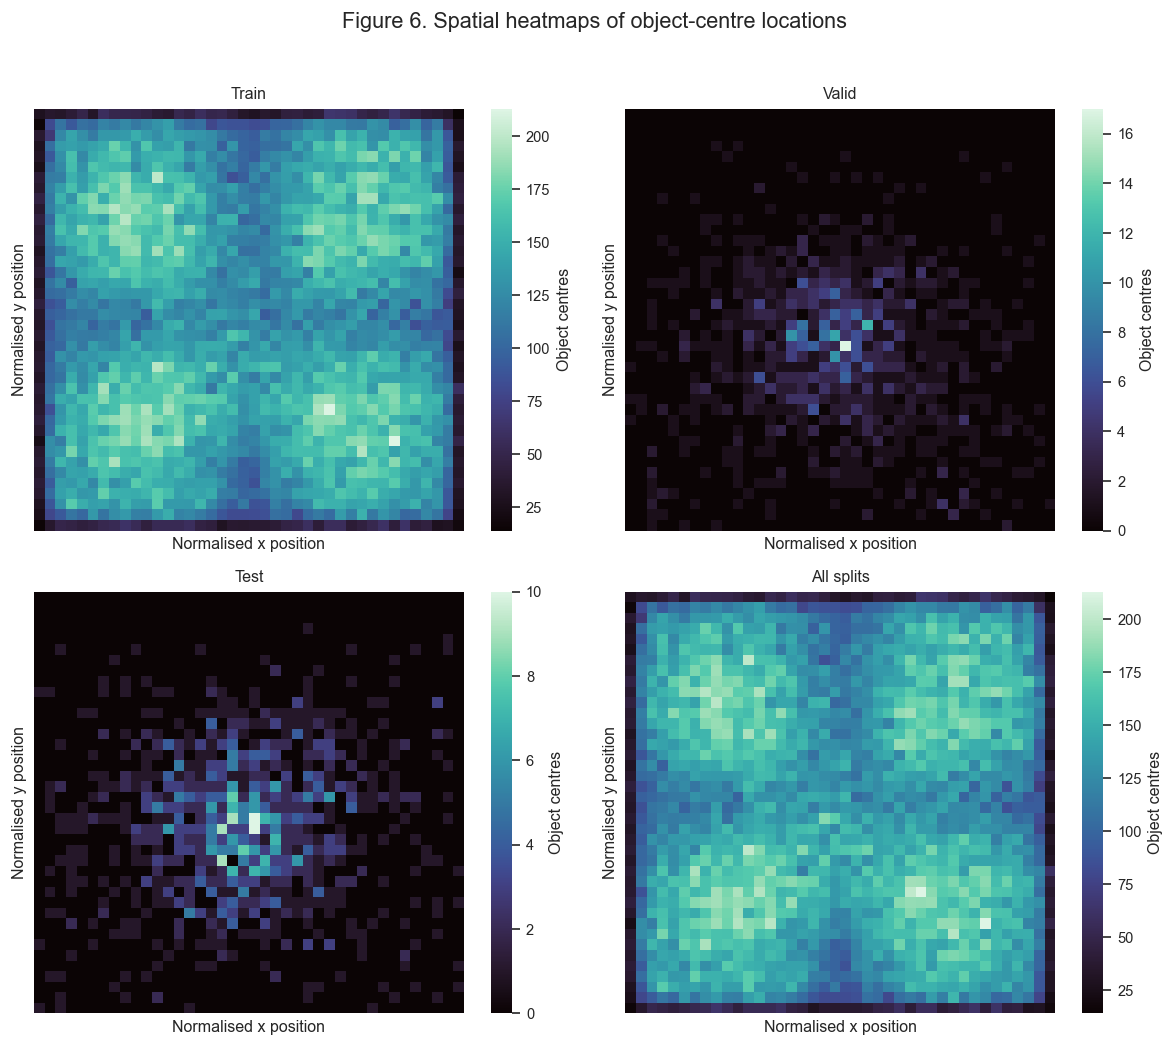

**Caption.** Heatmaps show normalised bounding-box centre density. Concentration away from image borders would indicate a centre-biased dataset, while strong split differences would suggest distribution shift.

In [8]:
def plot_center_heatmap(data: pd.DataFrame, ax, title: str, bins: int = 40):
    heat, xedges, yedges = np.histogram2d(
        data["x_center_norm"].clip(0, 1),
        data["y_center_norm"].clip(0, 1),
        bins=bins,
        range=[[0, 1], [0, 1]],
    )
    sns.heatmap(
        heat.T[::-1],
        ax=ax,
        cmap="mako",
        cbar=True,
        xticklabels=False,
        yticklabels=False,
        cbar_kws={"label": "Object centres"},
    )
    ax.set_title(title)
    ax.set_xlabel("Normalised x position")
    ax.set_ylabel("Normalised y position")

fig, axes = plt.subplots(2, 2, figsize=(10, 8.5))
for ax, split in zip(axes.flat[:3], SPLITS):
    plot_center_heatmap(boxes_df[boxes_df["split"] == split], ax, split.capitalize())
plot_center_heatmap(boxes_df, axes.flat[3], "All splits")
fig.suptitle("Figure 6. Spatial heatmaps of object-centre locations", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

display(Markdown("**Caption.** Heatmaps show normalised bounding-box centre density. Concentration away from image borders would indicate a centre-biased dataset, while strong split differences would suggest distribution shift."))


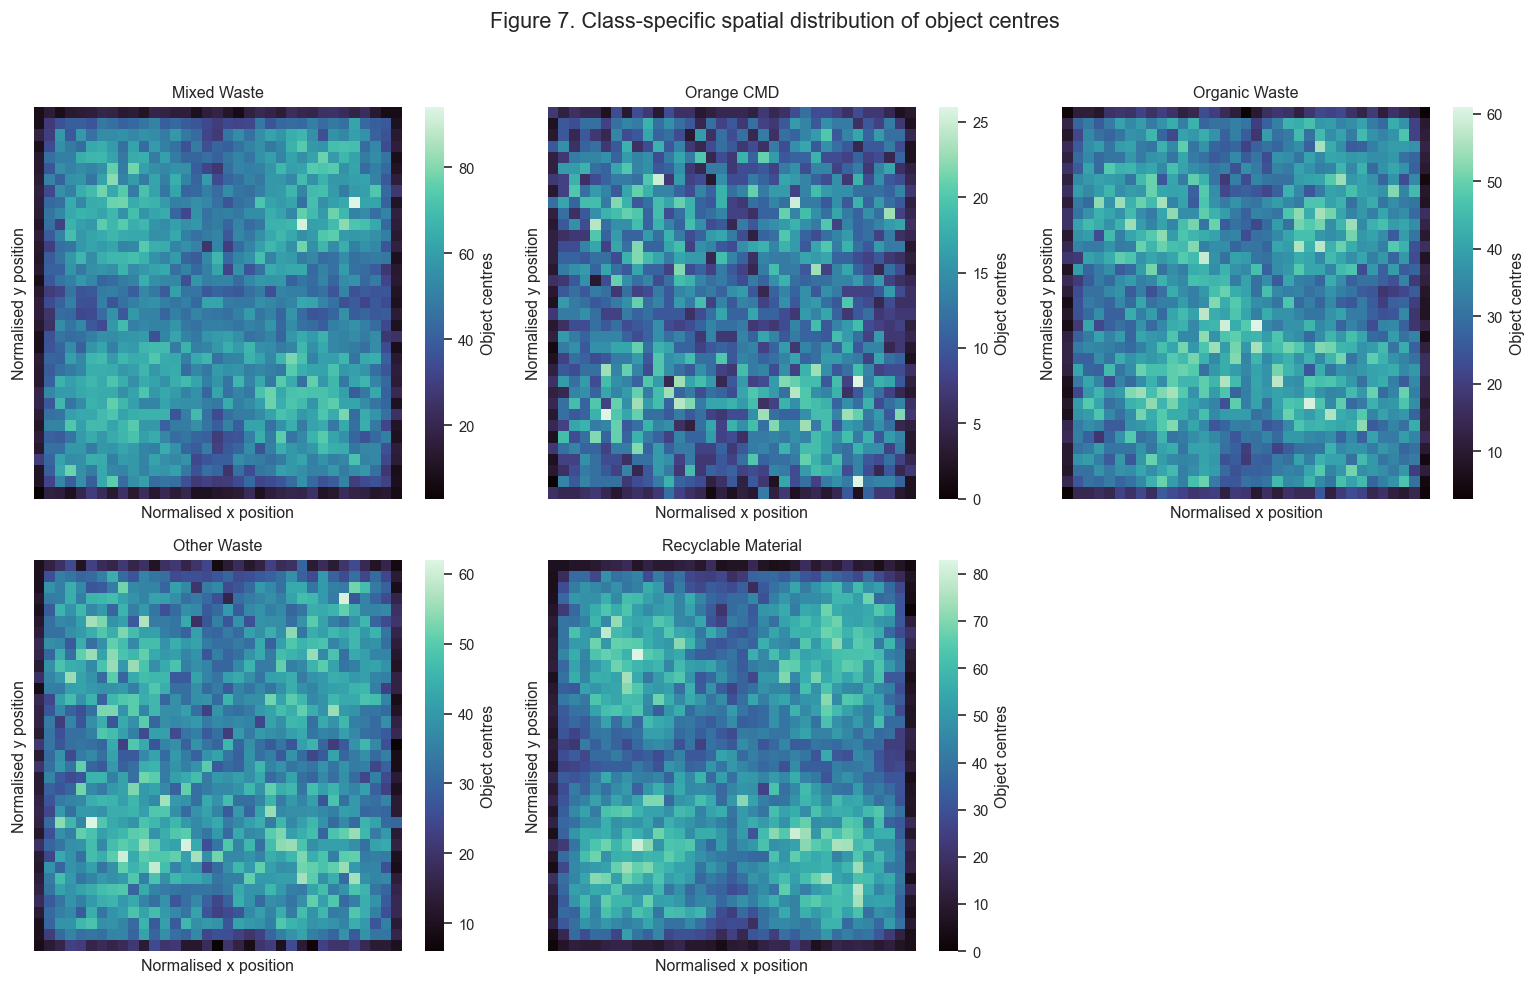

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, class_name in zip(axes.flat, CLASSES):
    plot_center_heatmap(boxes_df[boxes_df["class_name"] == class_name], ax, class_name, bins=35)
for ax in axes.flat[len(CLASSES):]:
    ax.axis("off")
fig.suptitle("Figure 7. Class-specific spatial distribution of object centres", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()


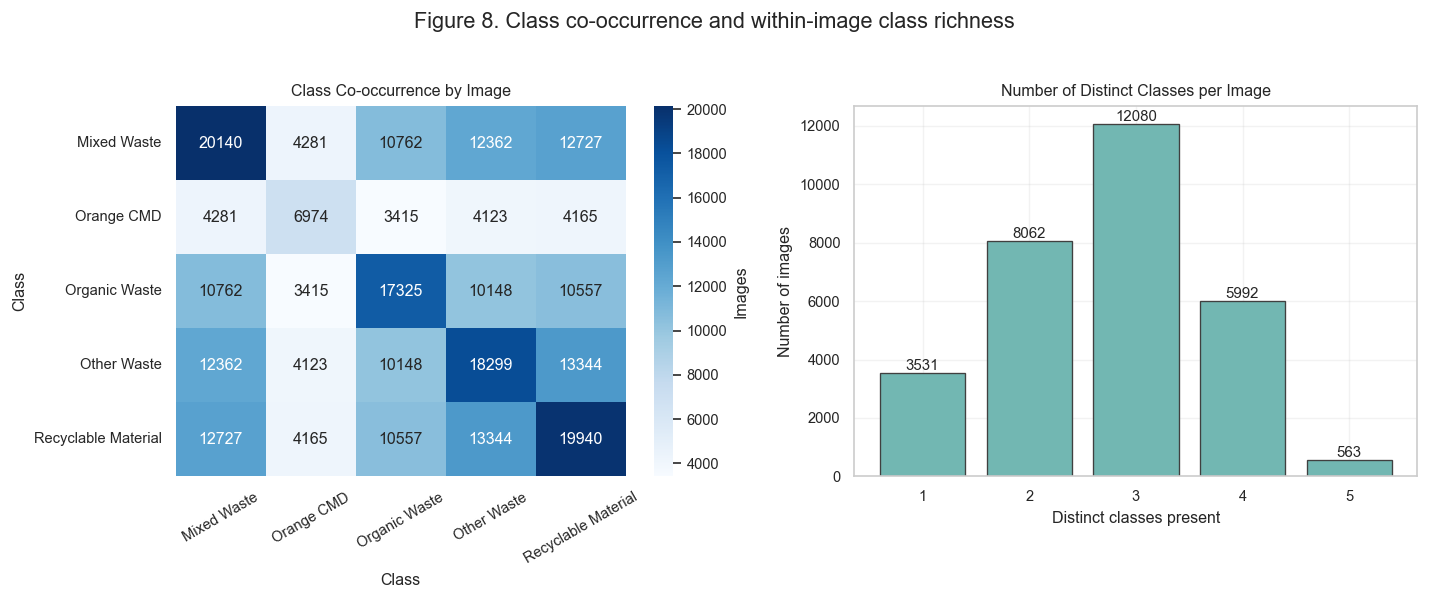

In [10]:
def cooccurrence_matrix(split: str | None = None) -> pd.DataFrame:
    data = boxes_df if split is None else boxes_df[boxes_df["split"] == split]
    matrix = pd.DataFrame(0, index=CLASSES, columns=CLASSES, dtype=int)
    for _, labels in data.groupby("image_id")["class_name"]:
        present = sorted(set(labels))
        for c1 in present:
            for c2 in present:
                matrix.loc[c1, c2] += 1
    return matrix

co_matrix = cooccurrence_matrix()
image_class_matrix = pd.crosstab(boxes_df["image_id"], boxes_df["class_name"]).reindex(columns=CLASSES, fill_value=0)
image_class_presence = (image_class_matrix > 0).astype(int)
richness_counts = image_class_presence.sum(axis=1).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
sns.heatmap(co_matrix, annot=True, fmt="d", cmap="Blues", ax=axes[0], cbar_kws={"label": "Images"})
axes[0].set_title("Class Co-occurrence by Image")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Class")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(richness_counts.index.astype(str), richness_counts.values, color="#72B7B2", edgecolor="0.25")
axes[1].set_title("Number of Distinct Classes per Image")
axes[1].set_xlabel("Distinct classes present")
axes[1].set_ylabel("Number of images")
for i, value in enumerate(richness_counts.values):
    axes[1].text(i, value + 2, f"{value}", ha="center", va="bottom", fontsize=9)

fig.suptitle("Figure 8. Class co-occurrence and within-image class richness", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()


## Dataset Diversity and Coverage

The dataset does not contain explicit geographic metadata. The following checks therefore focus on observable dataset coverage: image resolution diversity, Roboflow augmentation markers in filenames, and date-like strings where available. Filename-derived dates are treated cautiously because they depend on naming conventions rather than verified metadata.

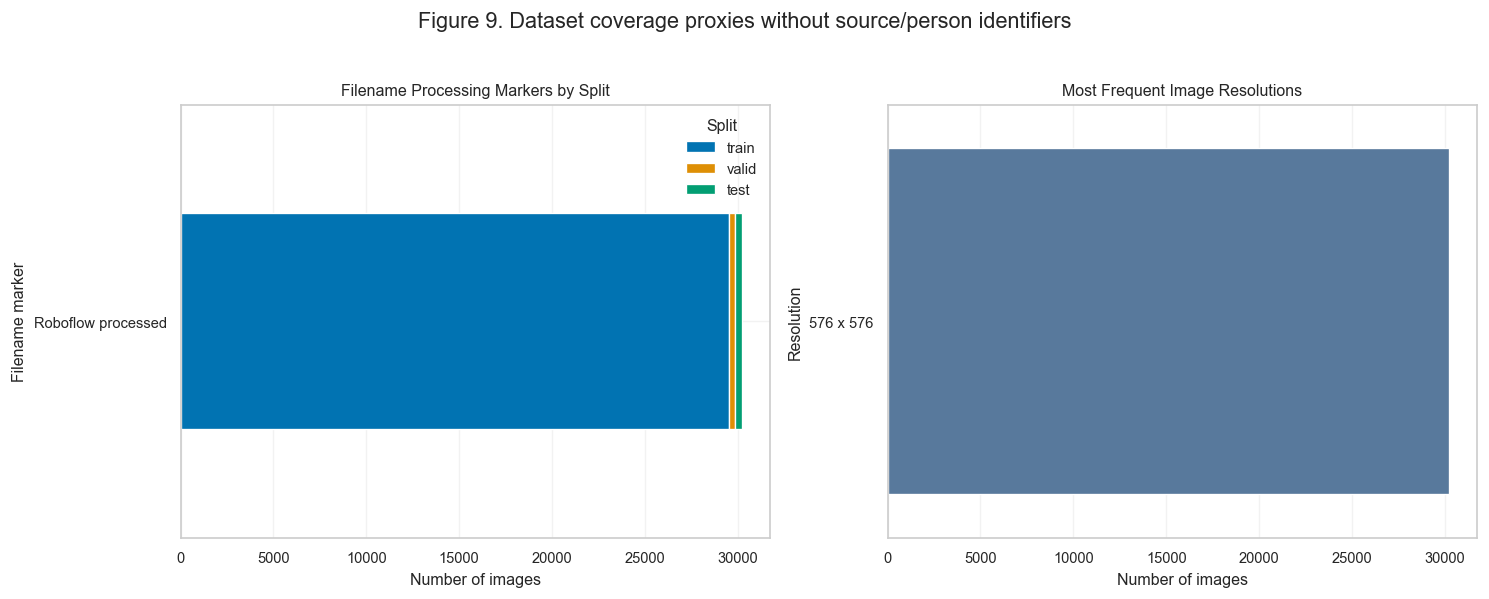

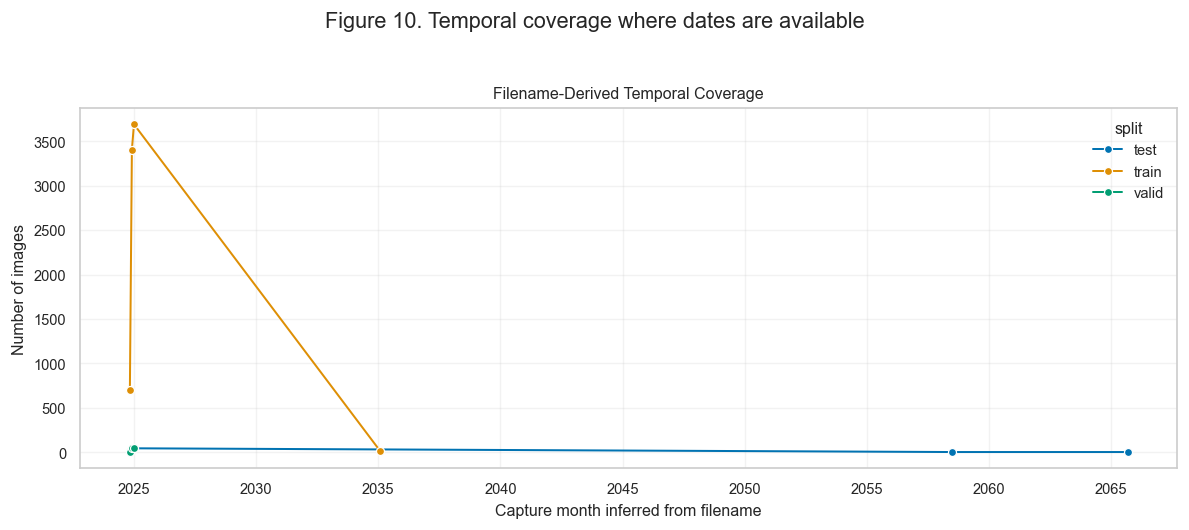

**Caption.** Roboflow-style filename markers are present in **100.0%** of images. The dataset contains **1 unique image resolutions**. Date-like strings were parsed for 7,994 of 30,236 images (26.4%). No explicit geographic fields were found in `data.yaml` or the YOLO annotation structure.

split,train,valid,test,total
file_name,,,,
Roboflow processed,29498,369,369,30236


In [11]:
augmentation_status = images_df["file_name"].str.contains(r"\.rf\.", regex=True).map({True: "Roboflow processed", False: "Original filename"})
augmentation_split = pd.crosstab(augmentation_status, images_df["split"]).reindex(columns=SPLITS, fill_value=0)
augmentation_split["total"] = augmentation_split.sum(axis=1)

resolution_df = images_df.copy()
resolution_df["resolution_label"] = resolution_df["width"].astype(str) + " x " + resolution_df["height"].astype(str)
top_resolutions = resolution_df["resolution_label"].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
augmentation_split[SPLITS].plot(kind="barh", stacked=True, ax=axes[0], color=sns.color_palette("colorblind", n_colors=len(SPLITS)))
axes[0].invert_yaxis()
axes[0].set_title("Filename Processing Markers by Split")
axes[0].set_xlabel("Number of images")
axes[0].set_ylabel("Filename marker")
axes[0].legend(title="Split")

sns.barplot(x=top_resolutions.values, y=top_resolutions.index, ax=axes[1], color="#4C78A8")
axes[1].set_title("Most Frequent Image Resolutions")
axes[1].set_xlabel("Number of images")
axes[1].set_ylabel("Resolution")

fig.suptitle("Figure 9. Dataset coverage proxies without source/person identifiers", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()

capture_dates = images_df.dropna(subset=["capture_date"]).copy()
if not capture_dates.empty:
    monthly = capture_dates.groupby([pd.Grouper(key="capture_date", freq="MS"), "split"]).size().reset_index(name="images")
    fig, ax = plt.subplots(figsize=(10, 4.2))
    sns.lineplot(data=monthly, x="capture_date", y="images", hue="split", marker="o", ax=ax, palette="colorblind")
    ax.set_title("Filename-Derived Temporal Coverage")
    ax.set_xlabel("Capture month inferred from filename")
    ax.set_ylabel("Number of images")
    fig.suptitle("Figure 10. Temporal coverage where dates are available", y=1.04, fontsize=13)
    fig.tight_layout()
    plt.show()
    date_caption = f"Date-like strings were parsed for {len(capture_dates):,} of {len(images_df):,} images ({len(capture_dates)/len(images_df)*100:.1f}%)."
else:
    date_caption = "No date-like filename strings were available for temporal analysis."

augmented_share = (augmentation_status == "Roboflow processed").mean() * 100
display(Markdown(
    f"**Caption.** Roboflow-style filename markers are present in **{augmented_share:.1f}%** of images. "
    f"The dataset contains **{resolution_df['resolution_label'].nunique():,} unique image resolutions**. {date_caption} "
    "No explicit geographic fields were found in `data.yaml` or the YOLO annotation structure."
))

display(augmentation_split.style.format("{:.0f}"))

## Correlation Analysis

Correlation analysis helps identify whether image characteristics and annotation characteristics are coupled. For example, a positive association between image area and object count may indicate that higher-resolution images preserve more visible objects, while a relationship between object count and mean box area may indicate crowding.


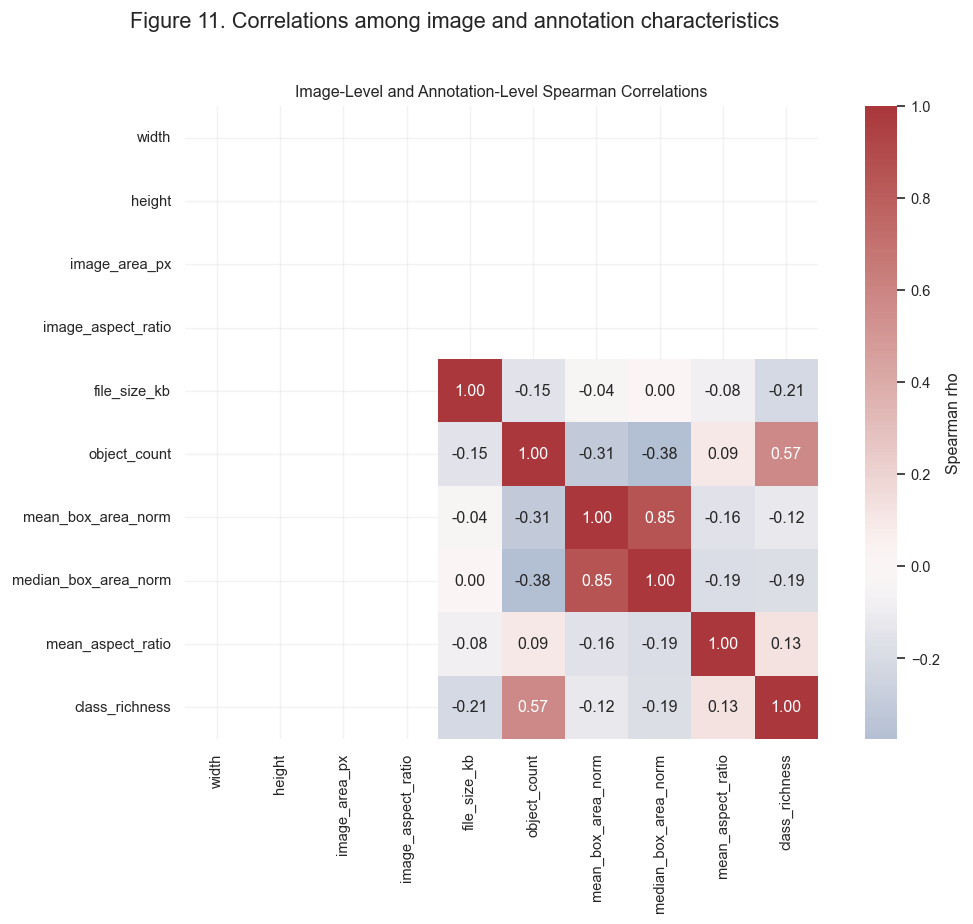

/var/folders/3g/sbfzk_x1691fk8l_9_1fht100000gn/T/ipykernel_29517/2431779439.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(correlation_df[left], correlation_df[right], nan_policy="omit")


,variable_1,variable_2,spearman_rho,p_value
0,object_count,mean_box_area_norm,-0.307,0
1,image_area_px,object_count,nan,nan
2,image_aspect_ratio,mean_aspect_ratio,nan,nan


In [12]:
corr_cols = [
    "width", "height", "image_area_px", "image_aspect_ratio", "file_size_kb",
    "object_count", "mean_box_area_norm", "median_box_area_norm", "mean_aspect_ratio", "class_richness",
]
correlation_df = images_df[corr_cols].copy()
correlation_matrix = correlation_df.corr(method="spearman")

fig, ax = plt.subplots(figsize=(9.5, 7.5))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, ax=ax, cbar_kws={"label": "Spearman rho"})
ax.set_title("Image-Level and Annotation-Level Spearman Correlations")
fig.suptitle("Figure 11. Correlations among image and annotation characteristics", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

pairs = [("object_count", "mean_box_area_norm"), ("image_area_px", "object_count"), ("image_aspect_ratio", "mean_aspect_ratio")]
rows = []
for left, right in pairs:
    rho, p = spearmanr(correlation_df[left], correlation_df[right], nan_policy="omit")
    rows.append({"variable_1": left, "variable_2": right, "spearman_rho": rho, "p_value": p})
display(pd.DataFrame(rows).style.format({"spearman_rho": "{:.3f}", "p_value": "{:.3g}"}))


## Annotation Quality Checks and Outlier Detection

This section checks for invalid labels and highlights images or boxes that may deserve manual review. Outliers are not automatically errors: very small objects, very large objects, and border-touching boxes may be legitimate, but they can disproportionately influence training dynamics and should be understood before model fitting.


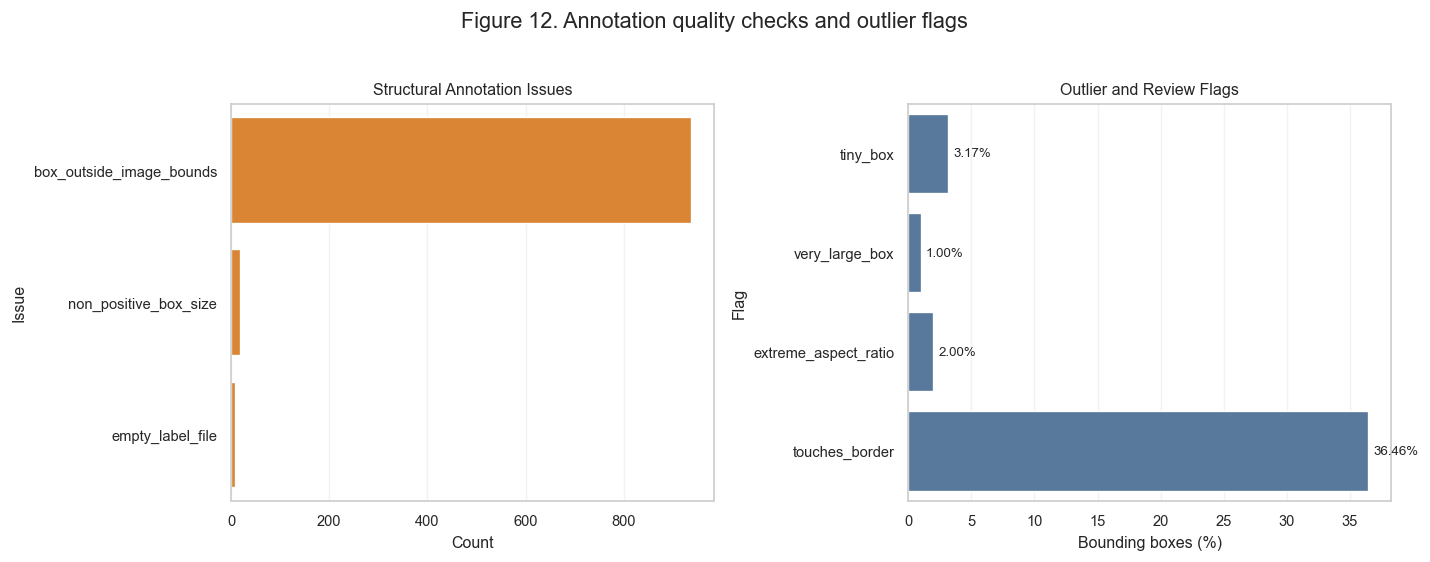

**Caption.** Structural parsing identified **964 quality flags**. Small-object review uses a threshold of **0.10%** of image area; the very-large threshold is the empirical 99th percentile (**20.57%** of image area).

,flag,count,share_%
0,tiny_box,6734,3.17
1,very_large_box,2124,1.00
2,extreme_aspect_ratio,4250,2.00
3,touches_border,77463,36.46


In [13]:
quality_summary = quality_issues["issue"].value_counts().rename_axis("issue").reset_index(name="count") if not quality_issues.empty else pd.DataFrame(columns=["issue", "count"])

tiny_threshold = 0.001
large_threshold = boxes_df["box_area_norm"].quantile(0.99)
aspect_low, aspect_high = boxes_df["aspect_ratio"].quantile([0.01, 0.99])

box_flags = boxes_df.assign(
    tiny_box=boxes_df["box_area_norm"] < tiny_threshold,
    very_large_box=boxes_df["box_area_norm"] > large_threshold,
    extreme_aspect_ratio=(boxes_df["aspect_ratio"] < aspect_low) | (boxes_df["aspect_ratio"] > aspect_high),
    touches_border=(boxes_df[["x_min_norm", "y_min_norm"]].le(0.01).any(axis=1) | boxes_df[["x_max_norm", "y_max_norm"]].ge(0.99).any(axis=1)),
)
flag_summary = box_flags[["tiny_box", "very_large_box", "extreme_aspect_ratio", "touches_border"]].sum().rename("count").reset_index().rename(columns={"index": "flag"})
flag_summary["share_%"] = flag_summary["count"] / len(box_flags) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
if not quality_summary.empty:
    sns.barplot(data=quality_summary, y="issue", x="count", ax=axes[0], color="#F58518")
else:
    axes[0].text(0.5, 0.5, "No structural label issues detected", ha="center", va="center", transform=axes[0].transAxes)
axes[0].set_title("Structural Annotation Issues")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Issue")

sns.barplot(data=flag_summary, y="flag", x="share_%", ax=axes[1], color="#4C78A8")
axes[1].set_title("Outlier and Review Flags")
axes[1].set_xlabel("Bounding boxes (%)")
axes[1].set_ylabel("Flag")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f%%", padding=3, fontsize=8)

fig.suptitle("Figure 12. Annotation quality checks and outlier flags", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()

display(Markdown(
    f"**Caption.** Structural parsing identified **{len(quality_issues):,} quality flags**. "
    f"Small-object review uses a threshold of **{tiny_threshold*100:.2f}%** of image area; the very-large threshold is the empirical 99th percentile (**{large_threshold*100:.2f}%** of image area)."
))
display(flag_summary.style.format({"count": "{:.0f}", "share_%": "{:.2f}"}))


In [14]:
outlier_images = (
    box_flags.groupby("image_id")[["tiny_box", "very_large_box", "extreme_aspect_ratio", "touches_border"]]
    .sum()
    .assign(total_flags=lambda d: d.sum(axis=1))
    .sort_values("total_flags", ascending=False)
    .head(15)
    .reset_index()
    .merge(images_df[["image_id", "split", "object_count"]], on="image_id", how="left")
)
outlier_review = outlier_images.drop(columns=["image_id"]).copy()
outlier_review.insert(0, "sample_ref", [f"review_{i:02d}" for i in range(1, len(outlier_review) + 1)])
display(outlier_review)


,sample_ref,tiny_box,very_large_box,extreme_aspect_ratio,touches_border,total_flags,split,object_count
0,review_01,11,0,1,16,28,train,30
1,review_02,22,0,2,3,27,train,28
2,review_03,10,0,9,5,24,train,16
3,review_04,11,0,9,2,22,train,15
4,review_05,12,0,8,2,22,train,17
5,review_06,12,0,1,9,22,train,29
6,review_07,3,0,0,19,22,train,26
7,review_08,6,0,0,15,21,train,22
8,review_09,12,0,4,4,20,train,18
9,review_10,12,0,3,4,19,train,30


## Representative Samples and Edge Cases

The next panels show qualitative examples selected deterministically from the parsed tables. The first panel samples common cases across the training split, while the second panel focuses on edge cases: high object count, very small boxes, very large boxes, extreme aspect ratios, and border-touching annotations.


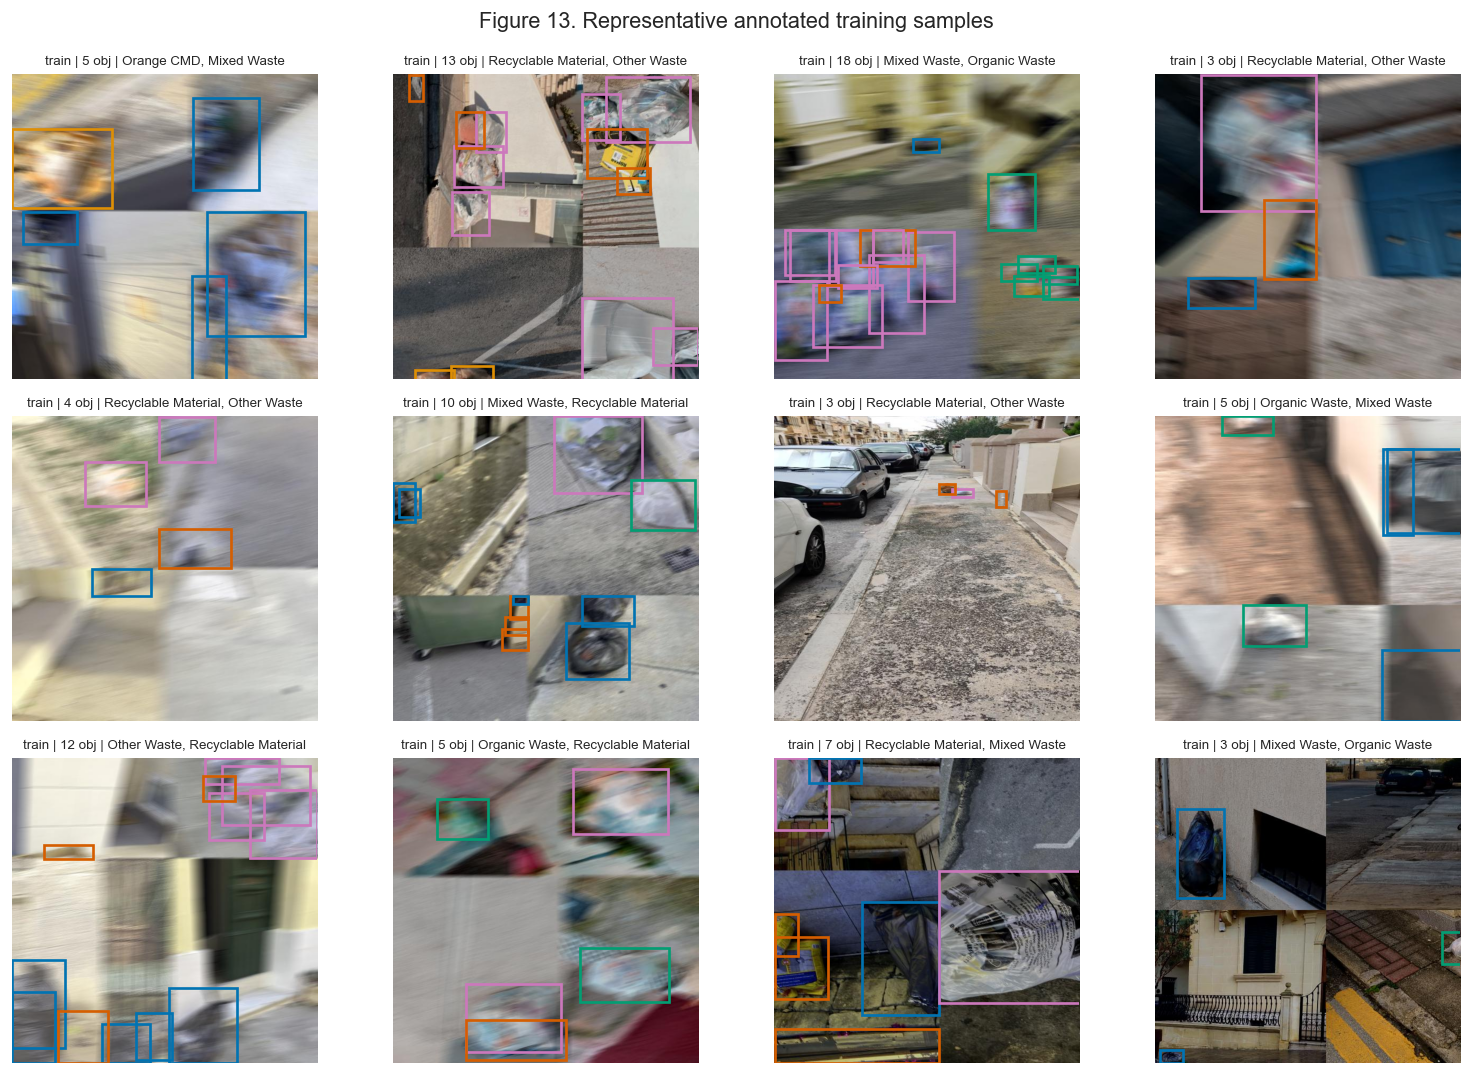

In [15]:
def read_rgb(path: Path) -> np.ndarray | None:
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        return None
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


def boxes_for_image(image_id: str) -> pd.DataFrame:
    return boxes_df[boxes_df["image_id"] == image_id]


def draw_image_with_boxes(ax, image_row: pd.Series, title: str | None = None):
    image = read_rgb(image_row["image_path"])
    if image is None:
        ax.text(0.5, 0.5, "Unreadable image", ha="center", va="center")
        ax.axis("off")
        return
    ax.imshow(image)
    for _, box in boxes_for_image(image_row["image_id"]).iterrows():
        x = box["x_min_norm"] * image_row["width"]
        y = box["y_min_norm"] * image_row["height"]
        w = box["box_width_norm"] * image_row["width"]
        h = box["box_height_norm"] * image_row["height"]
        color = CLASS_COLORS.get(box["class_name"], "black")
        rect = patches.Rectangle((x, y), w, h, linewidth=1.6, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
    ax.set_title(title or "Annotated sample", fontsize=8)
    ax.axis("off")

representative_ids = []
for class_name in CLASSES:
    candidates = boxes_df[(boxes_df["split"] == "train") & (boxes_df["class_name"] == class_name)]["image_id"].drop_duplicates()
    if len(candidates):
        representative_ids.append(candidates.sample(1, random_state=RANDOM_SEED + CLASS_TO_ID[class_name]).iloc[0])

extra_needed = max(0, 12 - len(representative_ids))
extra_ids = images_df[(images_df["split"] == "train") & (~images_df["image_id"].isin(representative_ids))].sample(extra_needed, random_state=RANDOM_SEED)["image_id"].tolist()
representative_ids = representative_ids + extra_ids
representative_rows = images_df.set_index("image_id").loc[representative_ids].reset_index()

fig, axes = plt.subplots(3, 4, figsize=(13, 9))
for ax, (_, row) in zip(axes.flat, representative_rows.iterrows()):
    classes_present = ", ".join(boxes_for_image(row["image_id"])["class_name"].drop_duplicates().tolist()[:2])
    title = f"{row['split']} | {row['object_count']} obj | {classes_present}"
    draw_image_with_boxes(ax, row, title)
fig.suptitle("Figure 13. Representative annotated training samples", y=0.99, fontsize=13)
fig.tight_layout()
plt.show()


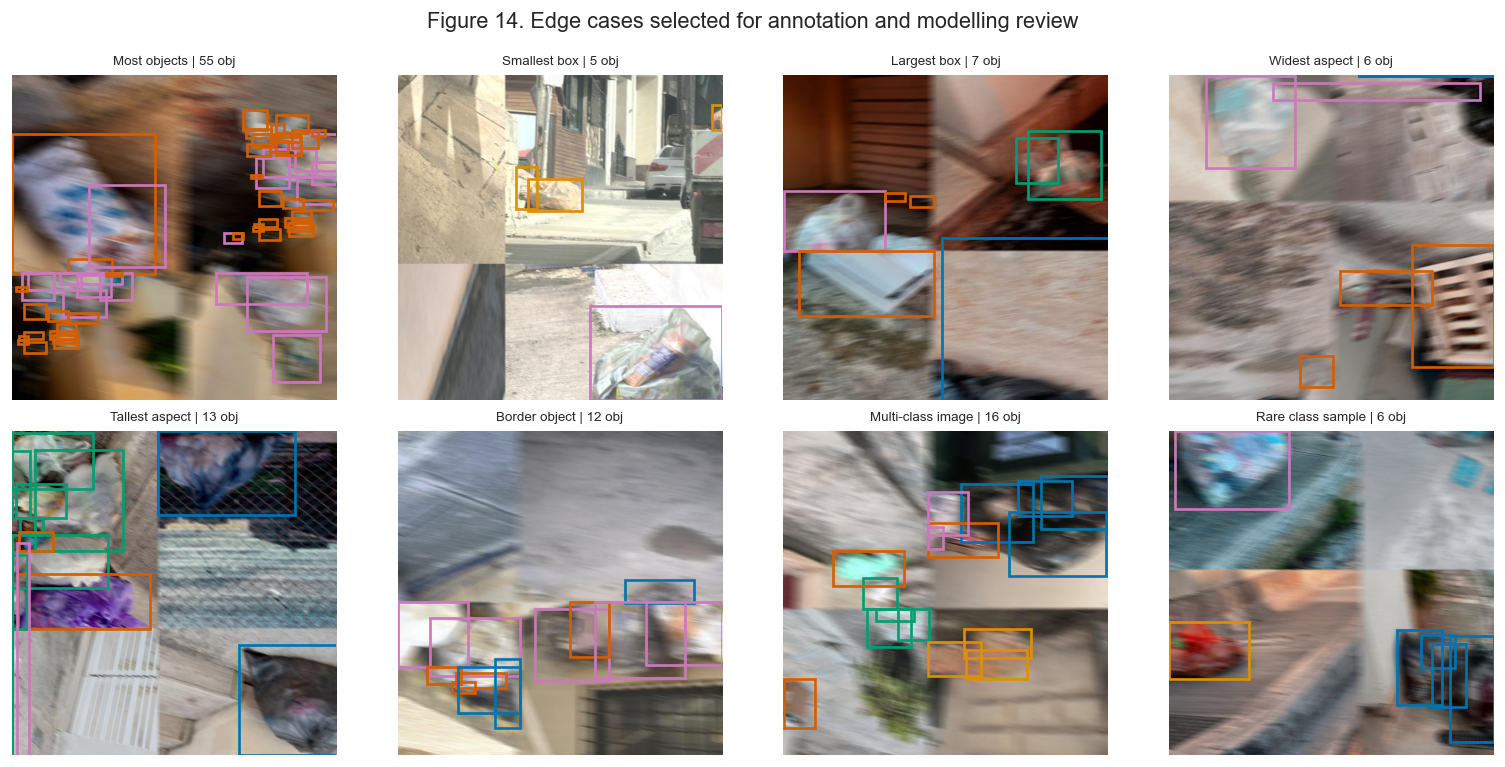

In [16]:
edge_cases = []

def append_case(label: str, image_id: str | None):
    if image_id and image_id not in [case[1] for case in edge_cases]:
        edge_cases.append((label, image_id))

append_case("Most objects", images_df.sort_values("object_count", ascending=False).iloc[0]["image_id"])
append_case("Smallest box", boxes_df.sort_values("box_area_norm", ascending=True).iloc[0]["image_id"])
append_case("Largest box", boxes_df.sort_values("box_area_norm", ascending=False).iloc[0]["image_id"])
append_case("Widest aspect", boxes_df.sort_values("aspect_ratio", ascending=False).iloc[0]["image_id"])
append_case("Tallest aspect", boxes_df.sort_values("aspect_ratio", ascending=True).iloc[0]["image_id"])
append_case("Border object", box_flags[box_flags["touches_border"]].iloc[0]["image_id"] if box_flags["touches_border"].any() else None)
append_case("Multi-class image", image_class_presence.sum(axis=1).sort_values(ascending=False).index[0])
append_case("Rare class sample", boxes_df[boxes_df["class_name"] == class_totals.idxmin()].iloc[0]["image_id"])

edge_rows = images_df.set_index("image_id").loc[[case[1] for case in edge_cases]].reset_index()
case_labels = dict(edge_cases)
case_labels = {image_id: label for label, image_id in edge_cases}

cols = 4
rows = math.ceil(len(edge_rows) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(13, 3.2 * rows))
axes = np.atleast_1d(axes).ravel()
for ax, (_, row) in zip(axes, edge_rows.iterrows()):
    draw_image_with_boxes(ax, row, f"{case_labels[row['image_id']]} | {row['object_count']} obj")
for ax in axes[len(edge_rows):]:
    ax.axis("off")
fig.suptitle("Figure 14. Edge cases selected for annotation and modelling review", y=0.99, fontsize=13)
fig.tight_layout()
plt.show()


## Analytical Discussion and Implications for Model Training

The EDA above provides the empirical basis for dataset handling and model-design decisions. The next cell generates a concise dissertation-style interpretation from the computed statistics so that the discussion remains synchronised with the data.


In [17]:
majority_class = class_totals.idxmax()
minority_class = class_totals.idxmin()
train_share = split_percent.loc["train"]
valid_share = split_percent.loc["valid"]
test_share = split_percent.loc["test"]
median_objects = images_df["object_count"].median()
max_objects = images_df["object_count"].max()
median_area = boxes_df["box_area_norm"].median() * 100
small_share = (boxes_df["box_area_norm"] < tiny_threshold).mean() * 100
unique_res = images_df[["width", "height"]].drop_duplicates().shape[0]
quality_count = len(quality_issues)

discussion = f"""
### Key Findings

1. **Dataset scale and partitioning.** The dataset comprises **{len(images_df):,} images** and **{len(boxes_df):,} bounding boxes** across five waste-related classes. The split allocation is highly training-heavy: train **{train_share:.1f}%**, validation **{valid_share:.1f}%**, and test **{test_share:.1f}%** of images. This provides substantial training data but leaves comparatively small validation and test partitions, so evaluation confidence intervals should be reported where possible.

2. **Class balance.** The most frequent class is **{majority_class}** and the least frequent class is **{minority_class}**, producing a largest-to-smallest imbalance ratio of **{imbalance_ratio:.2f}:1**. This level of imbalance justifies monitoring per-class precision, recall, AP, and confusion matrices rather than relying only on aggregate mAP. If minority-class recall is weak, class-aware sampling, loss weighting, or targeted augmentation should be considered.

3. **Object density.** The median image contains **{median_objects:.0f}** annotated object(s), while the maximum is **{max_objects:.0f}**. Images with many objects are useful for assessing detection under clutter, but they may also make non-maximum suppression and small-object recall more challenging.

4. **Scale and geometry.** The median bounding box occupies **{median_area:.2f}%** of the image area, and **{small_share:.2f}%** of boxes fall below the small-object review threshold of {tiny_threshold*100:.2f}% of image area. This supports the use of sufficiently high input resolution, scale-aware augmentation, and careful inspection of small-object AP.

5. **Image diversity.** The dataset contains **{unique_res:,} unique image resolutions**. Filename-derived temporal indicators, where available, are useful for exploratory checks but should not be treated as definitive geographic or temporal labels.

6. **Annotation quality.** The parser recorded **{quality_count:,} structural quality flags**. Structural label issues should be corrected before final training where feasible; statistical outliers should be manually reviewed rather than automatically removed because edge objects and very small bags may represent real deployment conditions.

### Implications for Subsequent Methodology

The analysis supports a model-evaluation protocol that emphasises **per-class metrics**, **split-wise distribution checks**, **small-object performance**, and **qualitative error review**. Given the small validation/test proportions, later experiments should avoid excessive hyperparameter tuning on the validation set and should reserve the test set strictly for final comparison. The observed class imbalance and object-scale variation also justify augmentation strategies that preserve annotation geometry, such as scale jitter, moderate photometric augmentation, and class-aware sampling, while avoiding transformations that distort already-small objects.
"""

display(Markdown(discussion))



### Key Findings

1. **Dataset scale and partitioning.** The dataset comprises **30,236 images** and **212,452 bounding boxes** across five waste-related classes. The split allocation is highly training-heavy: train **97.6%**, validation **1.2%**, and test **1.2%** of images. This provides substantial training data but leaves comparatively small validation and test partitions, so evaluation confidence intervals should be reported where possible.

2. **Class balance.** The most frequent class is **Mixed Waste** and the least frequent class is **Orange CMD**, producing a largest-to-smallest imbalance ratio of **4.13:1**. This level of imbalance justifies monitoring per-class precision, recall, AP, and confusion matrices rather than relying only on aggregate mAP. If minority-class recall is weak, class-aware sampling, loss weighting, or targeted augmentation should be considered.

3. **Object density.** The median image contains **6** annotated object(s), while the maximum is **55**. Images with many objects are useful for assessing detection under clutter, but they may also make non-maximum suppression and small-object recall more challenging.

4. **Scale and geometry.** The median bounding box occupies **2.34%** of the image area, and **3.17%** of boxes fall below the small-object review threshold of 0.10% of image area. This supports the use of sufficiently high input resolution, scale-aware augmentation, and careful inspection of small-object AP.

5. **Image diversity.** The dataset contains **1 unique image resolutions**. Filename-derived temporal indicators, where available, are useful for exploratory checks but should not be treated as definitive geographic or temporal labels.

6. **Annotation quality.** The parser recorded **964 structural quality flags**. Structural label issues should be corrected before final training where feasible; statistical outliers should be manually reviewed rather than automatically removed because edge objects and very small bags may represent real deployment conditions.

### Implications for Subsequent Methodology

The analysis supports a model-evaluation protocol that emphasises **per-class metrics**, **split-wise distribution checks**, **small-object performance**, and **qualitative error review**. Given the small validation/test proportions, later experiments should avoid excessive hyperparameter tuning on the validation set and should reserve the test set strictly for final comparison. The observed class imbalance and object-scale variation also justify augmentation strategies that preserve annotation geometry, such as scale jitter, moderate photometric augmentation, and class-aware sampling, while avoiding transformations that distort already-small objects.
